## FashionMNIST using ANN

## Step 1 : Import Libraries

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report


## Step 2 : Load dataset

In [2]:
(x_train,y_train),(x_test,y_test)= fashion_mnist.load_data()
# Flatten images
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

## Step 3 : Data Preprocessing

In [3]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 784)
(10000, 784)
(60000,)
(10000,)


## Step 4 : Build ANN Model

In [4]:
model=Sequential()

model.add(Dense(128,activation='relu',input_shape=(784,)))

model.add(Dense(64,activation='relu'))

model.add(Dense(10,activation='softmax'))

C:\Users\ACER\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 5 : Compile Model

In [5]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

## Step 6 : Train the model

In [6]:
history=model.fit(
x_train,
y_train,
epochs=10,
validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8199 - loss: 0.5081 - val_accuracy: 0.8581 - val_loss: 0.4004
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8626 - loss: 0.3765 - val_accuracy: 0.8651 - val_loss: 0.3753
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8750 - loss: 0.3389 - val_accuracy: 0.8672 - val_loss: 0.3624
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8831 - loss: 0.3162 - val_accuracy: 0.8658 - val_loss: 0.3776
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8904 - loss: 0.2965 - val_accuracy: 0.8688 - val_loss: 0.3673
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8950 - loss: 0.2829 - val_accuracy: 0.8837 - val_loss: 0.3213
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8984 - loss: 0.2694 - val_accuracy: 0.8825 - val_loss: 0.3304
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.9030 - loss: 0.2

## Step 7 : Training and Validation Graphs

In [7]:
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Accuracy: {accuracy:.4f}")
print(f"Loss: {loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8816 - loss: 0.3464
Accuracy: 0.8816
Loss: 0.3464


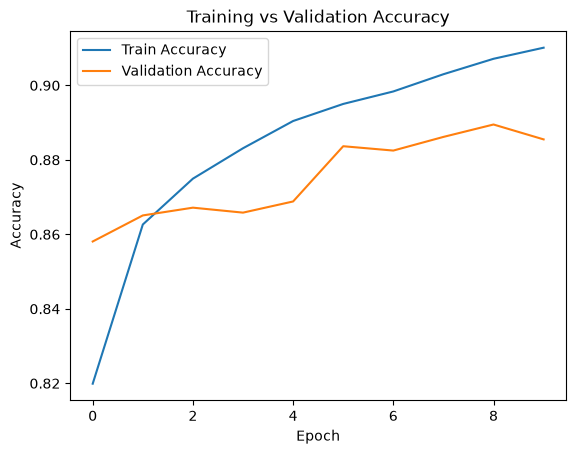

In [8]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()

## Step 8 : Confusion Matrix

In [9]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_classes)

print(cm)

[[823   4  23  45   5   0  93   1   6   0]
 [  2 973   2  17   3   0   2   0   0   1]
 [ 12   0 780  20 143   0  41   0   4   0]
 [ 21  16  10 901  36   1  12   0   3   0]
 [  1   1  69  29 870   0  28   0   2   0]
 [  0   0   0   0   0 968   0  18   1  13]
 [107   1  93  47 116   0 624   0  12   0]
 [  0   0   0   0   0  30   0 954   1  15]
 [  3   0   4   5   7   3   1   3 974   0]
 [  0   0   0   1   0   6   1  43   0 949]]


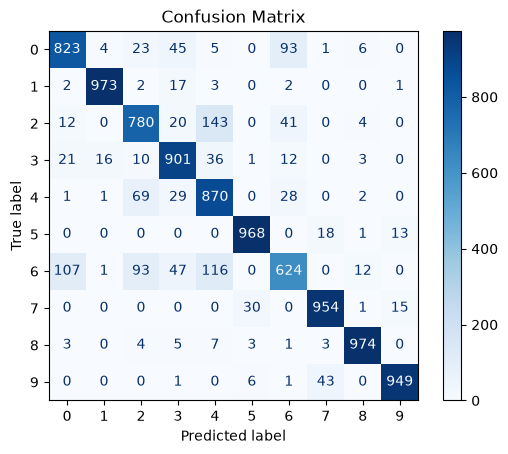

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## Step 9 : Plot loss

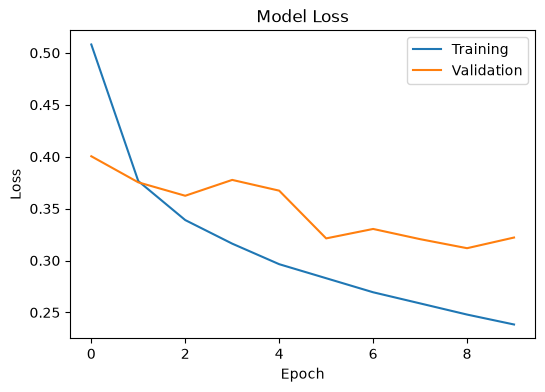

In [12]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 10 : Predict

In [13]:
y_pred = model.predict(x_test)

y_pred = (y_pred > 0.5).astype(int)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


## Step 11 : Precision, Recall, F1-score

In [19]:
import numpy as np
y_pred_labels = np.argmax(y_pred, axis=1)   # convert one-hot predictions to class labels
print(classification_report(y_test, y_pred_labels))


              precision    recall  f1-score   support

           0       0.69      0.87      0.77      1000
           1       0.98      0.97      0.98      1000
           2       0.82      0.75      0.78      1000
           3       0.87      0.88      0.88      1000
           4       0.76      0.85      0.80      1000
           5       0.96      0.97      0.97      1000
           6       0.82      0.58      0.68      1000
           7       0.94      0.95      0.95      1000
           8       0.98      0.97      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



## Step 12 : Predict on a New Sample

In [21]:
sample = x_test[0].reshape(1, 784)
prediction = model.predict(sample)


print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[[6.9854786e-06 1.7184849e-06 2.1977703e-06 2.9783982e-07 8.0091340e-06
  1.2582720e-04 2.2182454e-05 5.2330699e-02 3.5260887e-06 9.4749850e-01]]
